In [18]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import SparkSession

# 1. Membangun koneksi Spark ke MinIO beserta driver S3/AWS
spark = SparkSession.builder \
    .appName("EmployeeAttrition_SilverLayer") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://bda-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("✅ Spark Session berhasil dibuat, paket AWS/S3 terunduh, dan terhubung ke MinIO!")

# 2. Menarik Training Data dari MinIO
# (Pastikan file_path ini sudah sesuai dengan rute yang Anda temukan)
file_path = "s3a://datalake/bronze/train/train.csv" 

df_train = spark.read.csv(file_path, header=True, inferSchema=True)

# 3. Menampilkan 5 baris pertama dan struktur datanya
print("Preview Data Karyawan:")
display(df_train.limit(5).toPandas())

print("Skema Data (Tipe Kolom):")
df_train.printSchema()

✅ Spark Session berhasil dibuat, paket AWS/S3 terunduh, dan terhubung ke MinIO!
Preview Data Karyawan:


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


Skema Data (Tipe Kolom):
root
 |-- Employee ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Years at Company: integer (nullable = true)
 |-- Job Role: string (nullable = true)
 |-- Monthly Income: integer (nullable = true)
 |-- Work-Life Balance: string (nullable = true)
 |-- Job Satisfaction: string (nullable = true)
 |-- Performance Rating: string (nullable = true)
 |-- Number of Promotions: integer (nullable = true)
 |-- Overtime: string (nullable = true)
 |-- Distance from Home: integer (nullable = true)
 |-- Education Level: string (nullable = true)
 |-- Marital Status: string (nullable = true)
 |-- Number of Dependents: integer (nullable = true)
 |-- Job Level: string (nullable = true)
 |-- Company Size: string (nullable = true)
 |-- Company Tenure: integer (nullable = true)
 |-- Remote Work: string (nullable = true)
 |-- Leadership Opportunities: string (nullable = true)
 |-- Innovation Opportunities: string (nullable 

📊 Distribusi Attrition:


,Attrition,count,pct
0,Left,28338,47.55
1,Stayed,31260,52.45


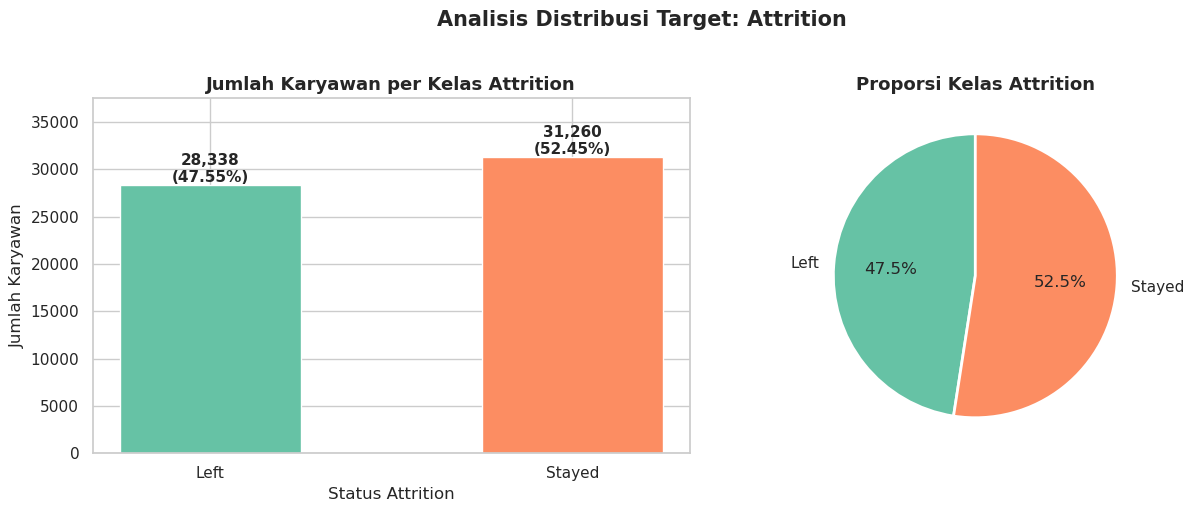

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", palette="Set2")

# ── Distribusi kelas Attrition ───────────────────────────────────────────────
attrition_dist = (
    df_train.groupBy("Attrition")
            .count()
            .orderBy("Attrition")
            .toPandas()
)

total = attrition_dist["count"].sum()
attrition_dist["pct"] = (attrition_dist["count"] / total * 100).round(2)

print("📊 Distribusi Attrition:")
display(attrition_dist)

# ── Visualisasi ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart jumlah
bars = axes[0].bar(
    attrition_dist["Attrition"],
    attrition_dist["count"],
    color=["#66c2a5", "#fc8d62"],
    edgecolor="white",
    width=0.5
)
for bar, (_, row) in zip(bars, attrition_dist.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{int(row['count']):,}\n({row['pct']}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[0].set_title("Jumlah Karyawan per Kelas Attrition", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Status Attrition")
axes[0].set_ylabel("Jumlah Karyawan")
axes[0].set_ylim(0, attrition_dist["count"].max() * 1.2)

# Pie chart proporsi
axes[1].pie(
    attrition_dist["count"],
    labels=attrition_dist["Attrition"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[1].set_title("Proporsi Kelas Attrition", fontsize=13, fontweight="bold")

plt.suptitle("Analisis Distribusi Target: Attrition", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [32]:
from pyspark.sql.types import StringType, IntegerType, DoubleType, LongType

# ── Pisahkan fitur numerik dan kategorikal ───────────────────────────────────
EXCLUDE_COLS  = {"Employee ID", "Attrition"}
NUMERIC_TYPES = (IntegerType, DoubleType, LongType)

numerical_cols = [
    f.name for f in df_train.schema.fields
    if isinstance(f.dataType, NUMERIC_TYPES) and f.name not in EXCLUDE_COLS
]
categorical_cols = [
    f.name for f in df_train.schema.fields
    if isinstance(f.dataType, StringType) and f.name not in EXCLUDE_COLS
]

print(f"🔢 Fitur Numerik     ({len(numerical_cols)}) : {numerical_cols}")
print(f"🔤 Fitur Kategorikal ({len(categorical_cols)}) : {categorical_cols}")

# ── Statistik Deskriptif (tampilan rapi) ─────────────────────────────────────
print("\n📋 Statistik Deskriptif Fitur Numerik:")

summary_pd = (
    df_train.select(numerical_cols)
            .summary("count", "mean", "stddev", "min", "max")
            .toPandas()
            .set_index("summary")
            .rename(index={
                "count" : "Count",
                "mean"  : "Mean",
                "stddev": "Std Dev",
                "min"   : "Min",
                "max"   : "Max"
            })
)

summary_pd = summary_pd.astype(float)

display(
    summary_pd.style
        .format("{:,.2f}")
        .set_caption("📋 Statistik Deskriptif Fitur Numerik")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "14px"), ("font-weight", "bold"),
                       ("text-align", "left"), ("padding-bottom", "8px")]},
            {"selector": "thead th",
             "props": [("background-color", "#4C72B0"), ("color", "white"),
                       ("font-weight", "bold"), ("text-align", "center"),
                       ("padding", "8px 12px")]},
            {"selector": "tbody th",
             "props": [("background-color", "#f0f0f0"), ("font-weight", "bold"),
                       ("padding", "6px 12px")]},
            {"selector": "td",
             "props": [("text-align", "right"), ("padding", "6px 12px")]},
            {"selector": "tr:hover td",
             "props": [("background-color", "#eaf1fb")]},
        ])
        .highlight_max(axis=1, color="#d4edda")
        .highlight_min(axis=1, color="#fff3cd")
)

🔢 Fitur Numerik     (7) : ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']
🔤 Fitur Kategorikal (15) : ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

📋 Statistik Deskriptif Fitur Numerik:


,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
summary,,,,,,,
Count,"59,598.00","59,598.00","59,598.00","59,598.00","59,598.00","59,598.00","59,598.00"
Mean,38.57,15.75,"7,302.40",0.83,50.01,1.65,55.76
Std Dev,12.08,11.25,"2,151.46",0.99,28.47,1.56,25.41
Min,18.00,1.00,"1,316.00",0.00,1.00,0.00,2.00
Max,59.00,51.00,"16,149.00",4.00,99.00,6.00,128.00


/tmp/ipykernel_1536/440439075.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1536/440439075.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1536/440439075.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1536/440439075.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1536/440439075.py:16: FutureWarning: 

Passin

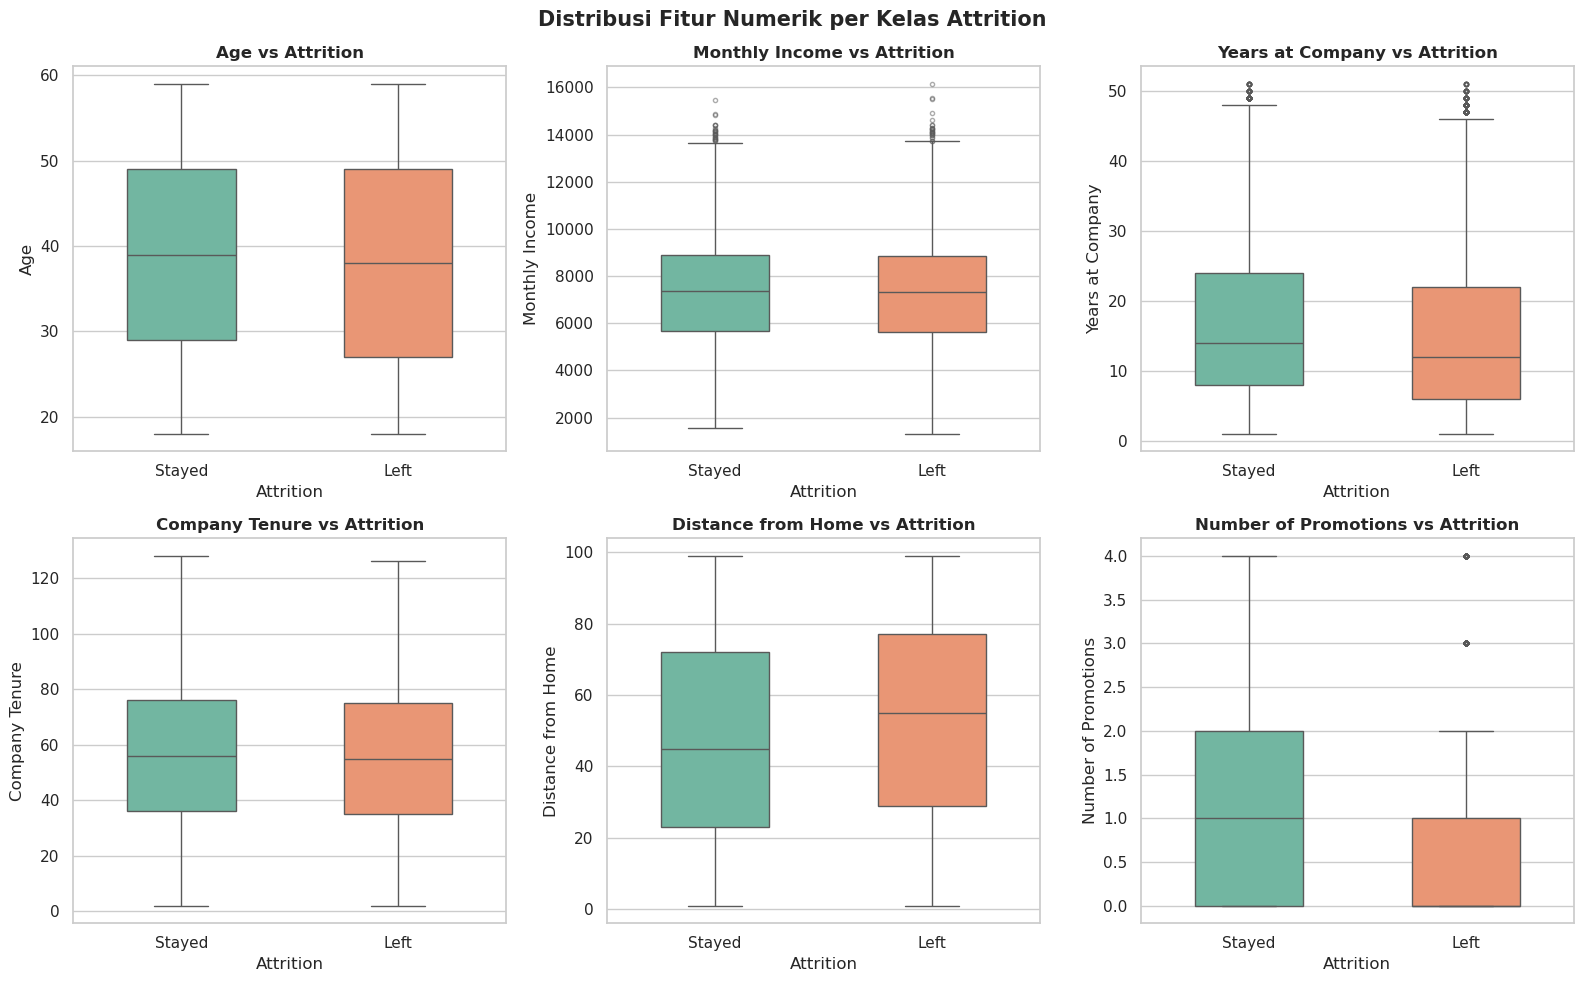

In [33]:
# ── 3a. Boxplot Fitur Numerik vs Attrition ───────────────────────────────────
# Ambil top-6 fitur numerik yang paling informatif
KEY_NUM = [c for c in ["Age", "Monthly Income", "Years at Company",
                        "Company Tenure", "Distance from Home",
                        "Number of Promotions"]
           if c in numerical_cols]

df_pd = df_train.select(KEY_NUM + ["Attrition"]).toPandas()

n_cols = 3
n_rows = -(-len(KEY_NUM) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col_name in enumerate(KEY_NUM):
    sns.boxplot(
        data=df_pd, x="Attrition", y=col_name,
        palette="Set2", ax=axes[i], width=0.5,
        flierprops=dict(marker="o", markersize=3, alpha=0.5)
    )
    axes[i].set_title(f"{col_name} vs Attrition", fontweight="bold")
    axes[i].set_xlabel("Attrition")
    axes[i].set_ylabel(col_name)

for j in range(i + 1, len(axes)):   # sembunyikan panel kosong
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur Numerik per Kelas Attrition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

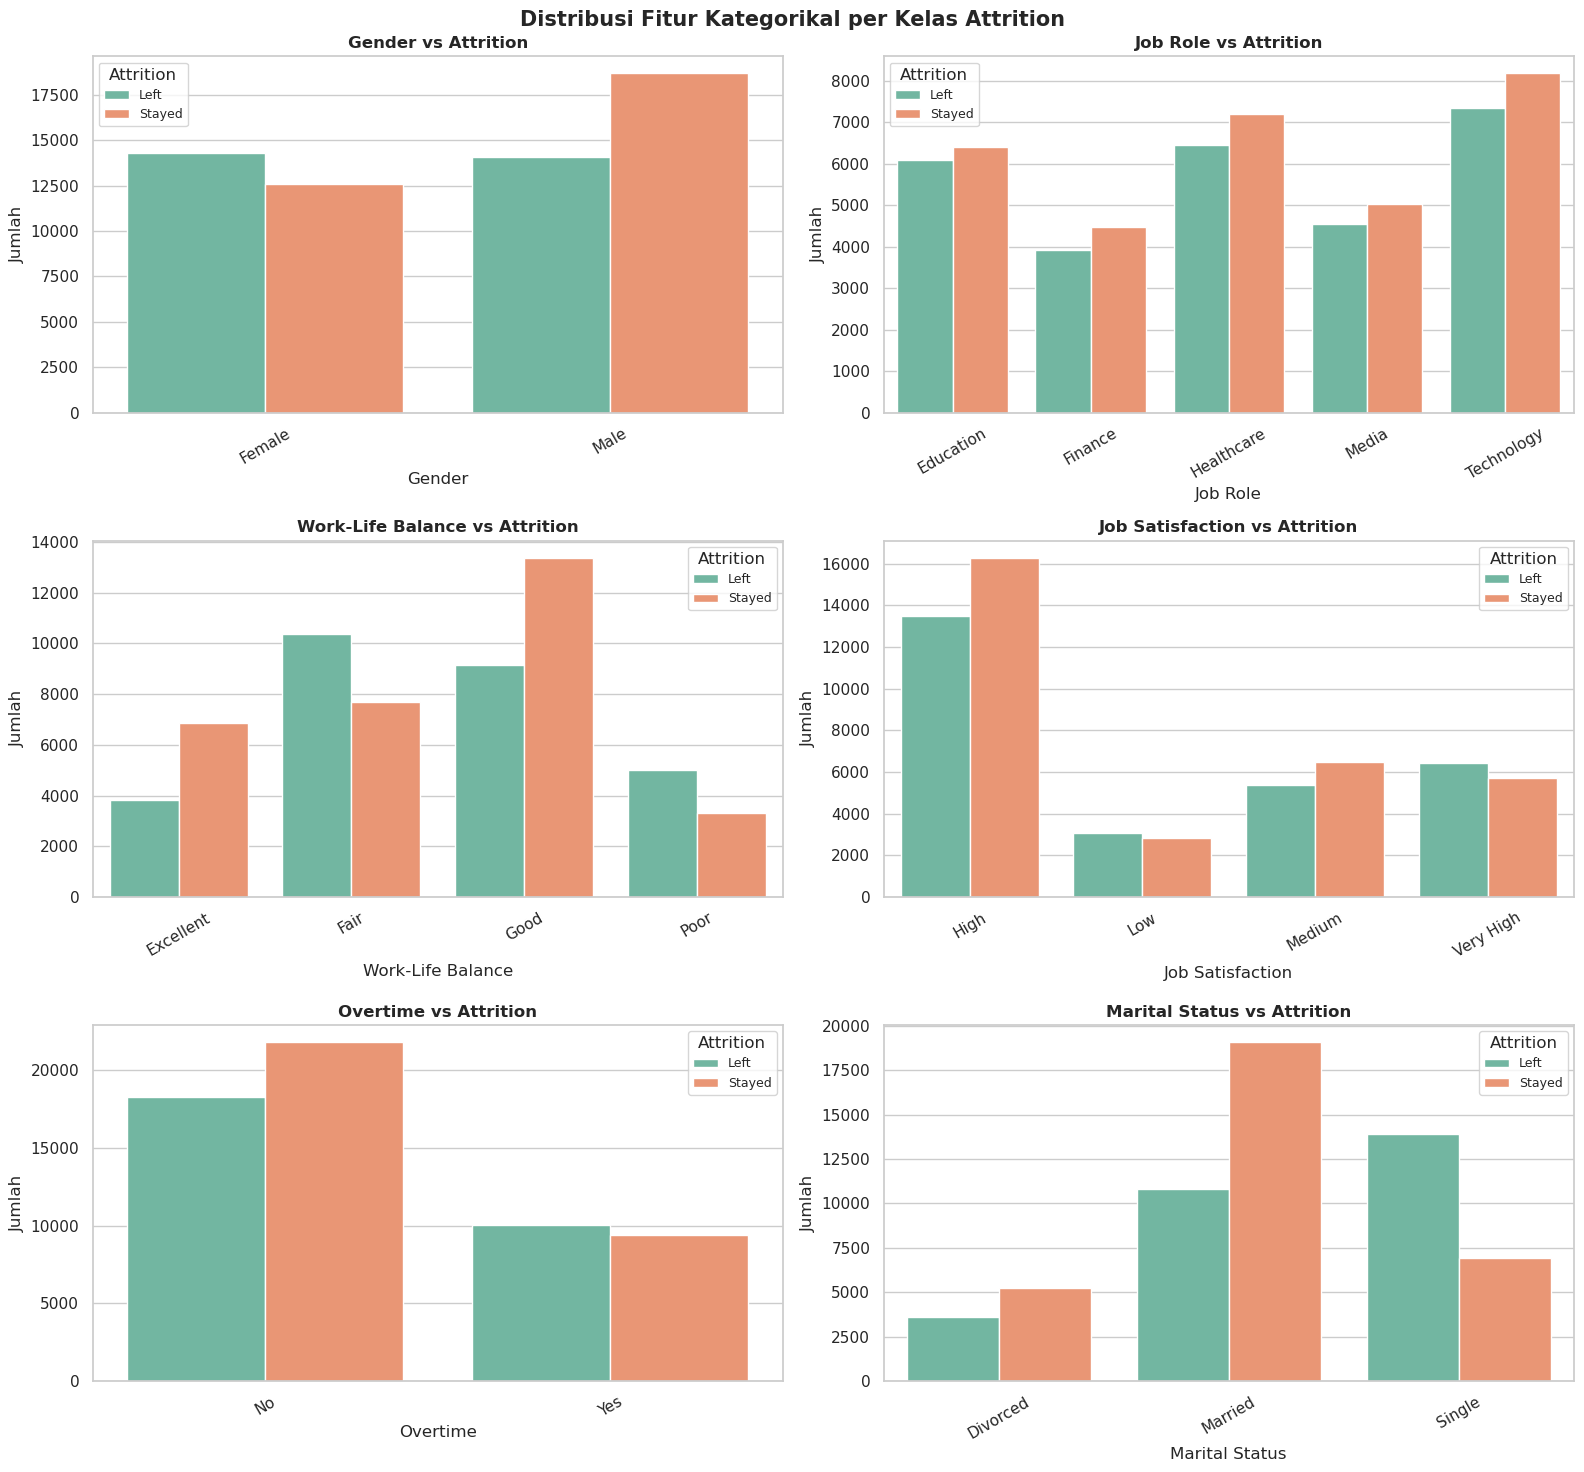

In [22]:
# ── 3b. Grouped Bar Chart Fitur Kategorikal vs Attrition ─────────────────────
KEY_CAT = [c for c in ["Gender", "Job Role", "Work-Life Balance",
                        "Job Satisfaction", "Overtime", "Marital Status"]
           if c in categorical_cols]

df_cat_pd = df_train.select(KEY_CAT + ["Attrition"]).toPandas()

n_cols = 2
n_rows = -(-len(KEY_CAT) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col_name in enumerate(KEY_CAT):
    ct = (
        df_cat_pd.groupby([col_name, "Attrition"])
                 .size()
                 .reset_index(name="count")
    )
    sns.barplot(
        data=ct, x=col_name, y="count", hue="Attrition",
        palette="Set2", ax=axes[i]
    )
    axes[i].set_title(f"{col_name} vs Attrition", fontweight="bold")
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel("Jumlah")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Attrition", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur Kategorikal per Kelas Attrition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
# Deteksi outlier menggunakan IQR per fitur numerik
from pyspark.sql.functions import percentile_approx

print("🔍 Deteksi Outlier (Metode IQR):")
for c in numerical_cols:
    q1, q3 = df_train.select(
        percentile_approx(c, 0.25),
        percentile_approx(c, 0.75)
    ).first()
    iqr     = q3 - q1
    lower   = q1 - 1.5 * iqr
    upper   = q3 + 1.5 * iqr
    n_out   = df_train.filter((col(c) < lower) | (col(c) > upper)).count()
    print(f"  {c:30s} → outlier: {n_out:,} baris (batas: {lower:.1f} – {upper:.1f})")

🔍 Deteksi Outlier (Metode IQR):
  Age                            → outlier: 0 baris (batas: -3.5 – 80.5)
  Years at Company               → outlier: 273 baris (batas: -17.0 – 47.0)
  Monthly Income                 → outlier: 50 baris (batas: 825.0 – 13713.0)
  Number of Promotions           → outlier: 0 baris (batas: -3.0 – 5.0)
  Distance from Home             → outlier: 0 baris (batas: -50.0 – 150.0)
  Number of Dependents           → outlier: 0 baris (batas: -4.5 – 7.5)
  Company Tenure                 → outlier: 0 baris (batas: -24.0 – 136.0)


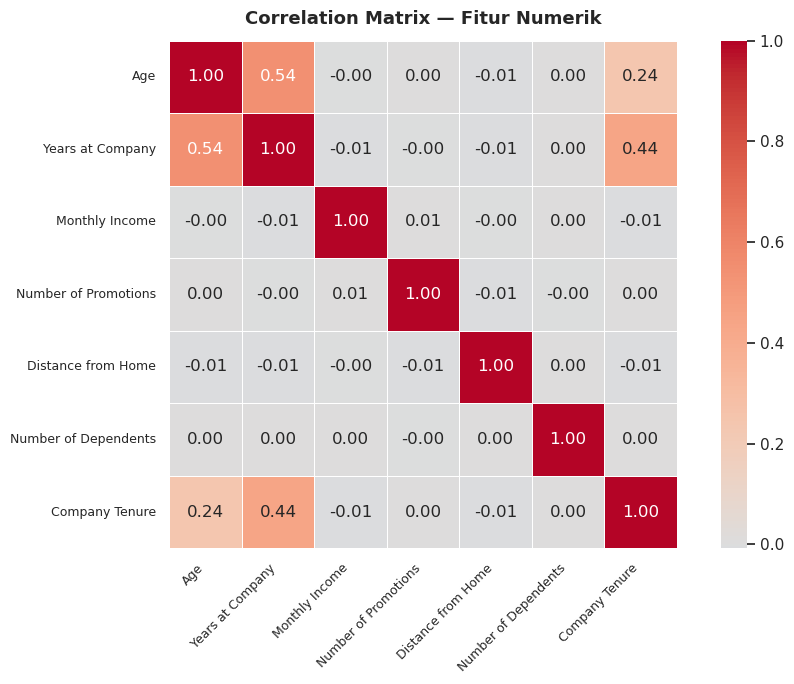

In [38]:
# ── Correlation Matrix Fitur Numerik ────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# Konversi ke Pandas untuk hitung korelasi
corr_pd = df_train.select(numerical_cols).toPandas().astype(float)
corr_matrix = corr_pd.corr()

# Visualisasi heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix — Fitur Numerik", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [24]:
from pyspark.sql.functions import col, isnan, when, count, trim
from pyspark.sql.types import StringType, DoubleType, FloatType

# ── 4a. Cek Missing Values ────────────────────────────────────────────────────
print("🔍 Pengecekan Missing Values:")

float_cols = [f.name for f in df_train.schema.fields if isinstance(f.dataType, (DoubleType, FloatType))]

missing_df = df_train.select([
    count(
        when(
            (isnan(c) | col(c).isNull()) if c in float_cols else col(c).isNull(),
            c
        )
    ).alias(c)
    for c in df_train.columns
])

missing_pd = missing_df.toPandas()
missing_cols_found = missing_pd.loc[:, (missing_pd != 0).any(axis=0)]

if missing_cols_found.empty:
    print("✅ Tidak ada missing values di semua kolom.")
else:
    print("⚠️  Ditemukan missing values:")
    display(missing_cols_found)

# ── 4b. Cek Duplikat ─────────────────────────────────────────────────────────
print("\n👯 Pengecekan Data Duplikat:")
total_rows   = df_train.count()
df_deduped   = df_train.dropDuplicates()
unique_rows  = df_deduped.count()
dup_count    = total_rows - unique_rows

print(f"  Total baris awal      : {total_rows:,}")
print(f"  Baris unik            : {unique_rows:,}")
print(f"  Baris duplikat        : {dup_count:,}")

if dup_count > 0:
    df_train = df_deduped
    print(f"  ✅ {dup_count} baris duplikat berhasil dihapus.")
else:
    print("  ✅ Tidak ada duplikat.")

🔍 Pengecekan Missing Values:
✅ Tidak ada missing values di semua kolom.

👯 Pengecekan Data Duplikat:
  Total baris awal      : 59,598
  Baris unik            : 59,598
  Baris duplikat        : 0
  ✅ Tidak ada duplikat.


In [25]:
# ── 4c. Trim whitespace kolom string & validasi tipe data ─────────────────────
from pyspark.sql.functions import trim

str_cols = [f.name for f in df_train.schema.fields if isinstance(f.dataType, StringType)]

# Trim whitespace pada semua kolom string
for c in str_cols:
    df_train = df_train.withColumn(c, trim(col(c)))

print(f"✅ Trim whitespace selesai pada {len(str_cols)} kolom string.")

# ── 4d. Imputasi missing values (jika ada) ─────────────────────────────────
# Numerik → isi dengan median | String → isi dengan "Unknown"
from pyspark.sql.functions import median as spark_median

if not missing_cols_found.empty:
    for c in missing_cols_found.columns:
        dtype = dict(df_train.dtypes)[c]
        if dtype in ("int", "double", "float", "long"):
            med_val = df_train.approxQuantile(c, [0.5], 0.0)[0]
            df_train = df_train.fillna({c: med_val})
            print(f"  🔢 '{c}' diisi median = {med_val}")
        else:
            df_train = df_train.fillna({c: "Unknown"})
            print(f"  🔤 '{c}' diisi 'Unknown'")
    print("✅ Imputasi selesai.")
else:
    print("✅ Tidak ada kolom yang perlu diimputasi.")

# ── 4e. Drop kolom ID yang tidak dibutuhkan model ──────────────────────────
if "Employee ID" in df_train.columns:
    df_train = df_train.drop("Employee ID")
    print("✅ Kolom 'Employee ID' di-drop (tidak relevan untuk model).")

print(f"\n📐 Dimensi setelah cleaning: {df_train.count():,} baris × {len(df_train.columns)} kolom")

✅ Trim whitespace selesai pada 16 kolom string.
✅ Tidak ada kolom yang perlu diimputasi.
✅ Kolom 'Employee ID' di-drop (tidak relevan untuk model).

📐 Dimensi setelah cleaning: 59,598 baris × 23 kolom


In [26]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.sql.types import StringType

# ── Identifikasi ulang kolom setelah cleaning ──────────────────────────────
TARGET_COL   = "Attrition"
EXCLUDE      = {TARGET_COL}

cat_cols = [
    f.name for f in df_train.schema.fields
    if isinstance(f.dataType, StringType) and f.name not in EXCLUDE
]
num_cols = [
    f.name for f in df_train.schema.fields
    if not isinstance(f.dataType, StringType) and f.name not in EXCLUDE
]

print(f"🔤 Kolom kategorikal yang akan di-encode ({len(cat_cols)}): {cat_cols}")
print(f"🔢 Kolom numerik yang akan dipakai ({len(num_cols)}): {num_cols}")

# ── StringIndexer: konversi string → indeks integer ─────────────────────────
# Output kolom: namaKolom_idx
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"   # nilai tak dikenal → indeks tambahan
    )
    for c in cat_cols
]

# StringIndexer juga untuk label target
label_indexer = StringIndexer(
    inputCol=TARGET_COL,
    outputCol="label",
    handleInvalid="keep"
)

# ── OneHotEncoder: indeks → vektor biner ────────────────────────────────────
# Output kolom: namaKolom_ohe
encoder = OneHotEncoder(
    inputCols =[f"{c}_idx" for c in cat_cols],
    outputCols=[f"{c}_ohe" for c in cat_cols],
    dropLast=True   # hindari multicollinearity (dummy variable trap)
)

print("\n✅ StringIndexer + OneHotEncoder berhasil dikonfigurasi.")

🔤 Kolom kategorikal yang akan di-encode (15): ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']
🔢 Kolom numerik yang akan dipakai (7): ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

✅ StringIndexer + OneHotEncoder berhasil dikonfigurasi.


In [27]:
from pyspark.ml.feature import VectorAssembler

# ── Daftar semua kolom input ke model ───────────────────────────────────────
# Numerik langsung dipakai | Kategorikal pakai hasil OHE
feature_cols = num_cols + [f"{c}_ohe" for c in cat_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"   # skip baris dengan nilai null di fitur
)

print(f"🧬 Total input fitur ke assembler : {len(feature_cols)}")
print(f"   - Fitur numerik                : {len(num_cols)}")
print(f"   - Fitur OHE (kategorikal)      : {len(cat_cols)}")
print(f"\n📌 Output kolom assembler         : 'features'")
print(f"📌 Output kolom label             : 'label'")

print("\n✅ VectorAssembler berhasil dikonfigurasi.")

🧬 Total input fitur ke assembler : 22
   - Fitur numerik                : 7
   - Fitur OHE (kategorikal)      : 15

📌 Output kolom assembler         : 'features'
📌 Output kolom label             : 'label'

✅ VectorAssembler berhasil dikonfigurasi.


In [28]:
# ── Bangun & jalankan pipeline Feature Engineering ──────────────────────────
fe_pipeline = Pipeline(stages=indexers + [label_indexer, encoder, assembler])

print("⚙️  Fitting pipeline Feature Engineering...")
fe_model   = fe_pipeline.fit(df_train)
df_encoded = fe_model.transform(df_train)

print("✅ Pipeline selesai. Kolom hasil encoding:")
df_encoded.select(["features", "label"]).show(5, truncate=True)

print(f"\n📐 Dimensi df_encoded: {df_encoded.count():,} baris × {len(df_encoded.columns)} kolom")

⚙️  Fitting pipeline Feature Engineering...
✅ Pipeline selesai. Kolom hasil encoding:
+--------------------+-----+
|            features|label|
+--------------------+-----+
|(56,[0,1,2,3,4,6,...|  0.0|
|(56,[0,1,2,3,4,5,...|  0.0|
|(56,[0,1,2,4,5,6,...|  0.0|
|(56,[0,1,2,3,4,5,...|  0.0|
|(56,[0,1,2,4,6,7,...|  0.0|
+--------------------+-----+
only showing top 5 rows


📐 Dimensi df_encoded: 59,598 baris × 55 kolom


In [37]:
# ── Simpan hasil ke zona processed/ MinIO ────────────────────────────────────
PROCESSED_PATH = "s3a://datalake/processed/employee-attrition/"

df_encoded.select("features", "label") \
    .write \
    .mode("overwrite") \
    .parquet(PROCESSED_PATH)

print(f"✅ Data processed berhasil disimpan ke MinIO:")
print(f"   Path  : {PROCESSED_PATH}")
print(f"   Format: Parquet")
print(f"   Baris : {df_encoded.count():,}")

✅ Data processed berhasil disimpan ke MinIO:
   Path  : s3a://datalake/processed/employee-attrition/
   Format: Parquet
   Baris : 59,598


In [35]:
# Stratified split 80:20 — proporsi label dijaga di tiap split
fractions = (
    df_model_ready
    .groupBy("label")
    .count()
    .rdd
    .map(lambda r: (r["label"], 0.8))
    .collectAsMap()
)

df_split_train = df_model_ready.sampleBy("label", fractions, seed=42)
df_split_test  = df_model_ready.subtract(df_split_train)

print(f"Train : {df_split_train.count():,} baris")
print(f"Test  : {df_split_test.count():,} baris")

# Validasi distribusi
df_split_train.groupBy("label").count().orderBy("label").show()
df_split_test.groupBy("label").count().orderBy("label").show()

Train : 47,826 baris
Test  : 11,772 baris
+-----+-----+
|label|count|
+-----+-----+
|  0.0|25053|
|  1.0|22773|
+-----+-----+

+-----+-----+
|label|count|
+-----+-----+
|  0.0| 6207|
|  1.0| 5565|
+-----+-----+



Train : 47,826 baris
Test  : 11,772 baris


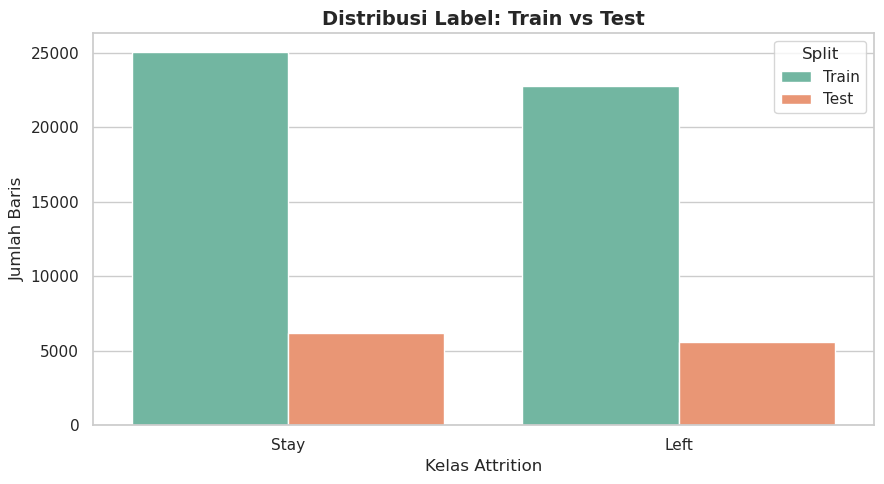


✅ Pipeline selesai! Data siap digunakan untuk training model.
   → Gunakan : df_split_train  dan  df_split_test


In [36]:
df_split_train, df_split_test = df_model_ready.randomSplit([0.8, 0.2], seed=42)

fractions = (
    df_model_ready
    .groupBy("label")
    .count()
    .rdd
    .map(lambda r: (r["label"], 0.8))
    .collectAsMap()
)

df_split_train = df_model_ready.sampleBy("label", fractions, seed=42)
df_split_test  = df_model_ready.subtract(df_split_train)

print(f"Train : {df_split_train.count():,} baris")
print(f"Test  : {df_split_test.count():,} baris")

train_dist = df_split_train.groupBy("label").count().toPandas().assign(split="Train")
test_dist  = df_split_test.groupBy("label").count().toPandas().assign(split="Test")
combined   = pd.concat([train_dist, test_dist])
combined["label"] = combined["label"].map({0: "Stay", 1: "Left"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=combined, x="label", y="count", hue="split", palette="Set2", ax=ax)
ax.set_title("Distribusi Label: Train vs Test", fontsize=14, fontweight="bold")
ax.set_xlabel("Kelas Attrition")
ax.set_ylabel("Jumlah Baris")
ax.legend(title="Split")
plt.tight_layout()
plt.show()

print("\n✅ Pipeline selesai! Data siap digunakan untuk training model.")
print("   → Gunakan : df_split_train  dan  df_split_test")